# Simple Linear Regression Demo 

**Goal:** Predict a person's **Salary** based on a single feature: `years_experience`.

This is called **simple regression** because there is only **one input feature** used to predict a **continuous number** (not a category like in classification).

We will use `salary_experience.csv` (make sure it's in the same folder as this notebook).

## Step 1: Import libraries

In [1]:
# ! pip install matplotlib pandas scikit-learn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Step 2: Load the dataset

In [2]:
df = pd.read_csv('salary_experience.csv')
df.head()

,years_experience,salary
0,1.1,35356.0
1,11.7,83660.0
2,6.6,59170.0
3,10.9,77812.0
4,14.7,90410.0


In [3]:
df.describe()

,years_experience,salary
count,60.000000,60.000000
mean,7.450000,63855.450000
std,3.847539,17770.929943
min,0.000000,30627.000000
25%,5.150000,53417.250000
50%,7.300000,63096.500000
75%,10.450000,76305.000000
max,14.700000,100103.000000


## Step 3: Visualize the relationship

It's always a good idea to plot the data first when you only have one feature.

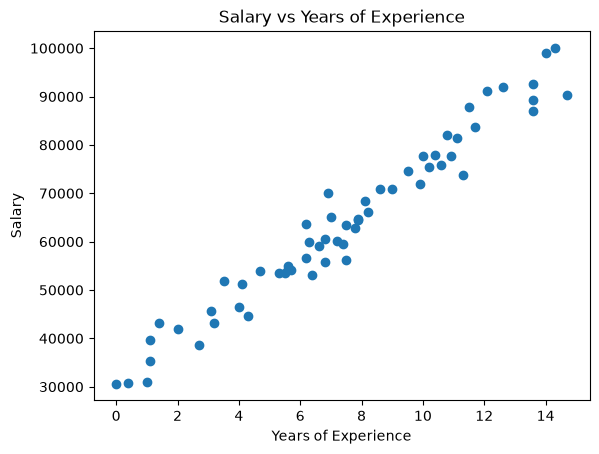

In [4]:
plt.scatter(df['years_experience'], df['salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Years of Experience')
plt.show()

## Step 4: Split data into features (X) and target (y)

In [5]:
X = df[['years_experience']]  # note: double brackets keep this a DataFrame, not a Series
y = df['salary']

## Step 5: Split into training and testing sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 48
Testing samples: 12


## Step 6: Train a Linear Regression model

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f'Slope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')

Slope (coefficient): 4428.96
Intercept: 30852.52


## Step 7: Make predictions on the test set

In [8]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({'actual': y_test.values, 'predicted': y_pred.round(2)})
comparison.head(10)

,actual,predicted
0,35356.0,35724.37
1,68456.0,66727.06
2,87868.0,81785.51
3,82076.0,78685.24
4,30941.0,35281.47
5,63607.0,58312.04
6,60037.0,62741.00
7,38692.0,42810.70
8,54116.0,56097.57
9,75867.0,77799.45


## Step 8: Visualize the fitted line

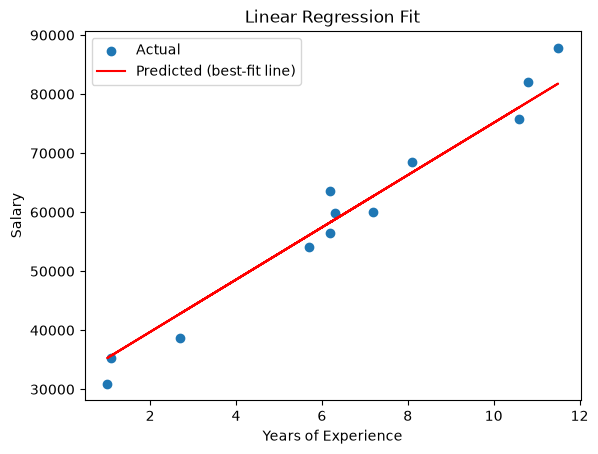

In [9]:
plt.scatter(X_test, y_test, label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted (best-fit line)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

## Step 9: Evaluate the model

For regression we don't use accuracy (that's for classification). Instead we use:
- **MAE** (Mean Absolute Error): average size of the error, in original units (dollars here)
- **RMSE** (Root Mean Squared Error): similar to MAE but penalizes larger errors more
- **R² score**: how much of the variation in salary is explained by the model (1.0 = perfect, 0 = no better than guessing the average)

In [10]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f'MAE:  {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2 score: {r2:.2f}')

MAE:  2906.98
RMSE: 3353.45
R2 score: 0.96


## Step 10: Predict salary for a new person

In [11]:
new_person = pd.DataFrame({'years_experience': [8]})
predicted_salary = model.predict(new_person)[0]
print(f'Predicted salary for 8 years experience: {predicted_salary:.2f}')

Predicted salary for 8 years experience: 66284.17


### Summary
- **Simple regression** = predicting a **number** using **one** input feature.
- We used `LinearRegression`, which fits a straight line: `salary = slope * years_experience + intercept`.
- Key metrics: **MAE**, **RMSE**, and **R²** (not accuracy — that's for classification).